In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_csv('../data/raw/gurgaon_property.csv')

In [3]:
df.head()

,Unnamed: 0,property_name,property_type,society,price,price_per_sq_fit,area,areaWithType,bedRoom,bathroom,...,agePossession,nearbyLocations,description,furnishDetails,features,rating,area_type,area_sqm,build_up,area_unit
0,0,2 BHK Flat in Sohna,flat,breez global hill view,0.35,6315.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,2,...,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",Property is on 14th floor and look towards ara...,[],"['Power Back-up', 'Security / Fire Alarm', 'Li...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,51.48,554.125572,sq.m.
1,1,2 BHK Flat in Sohna,flat,hcbs sports ville,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,...,undefined,"['The roadside cafe', 'GD Goenka Mess', 'ROyal...",Best in class property available at sohna loca...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Green Area4 out of 5', 'Amenities4 out of 5'...",Carpet area: 650 sq.ft. (60.39 sq.m.),69.68,750.028552,sq.m.
2,2,2 BHK Flat in Sector 92 Gurgaon,flat,sare crescent parc,0.49,4909.0,998.0,Carpet area: 998 (92.72 sq.m.),2,2,...,1 to 5 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...","On second floor, east facing bedrooms",NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4 out of 5', 'Amenities3 out of 5'...",NaN,92.72,998.028808,sq.m.
3,3,2 BHK Flat in Sector 89 Gurgaon,flat,greenopolis,0.80,4820.0,1660.0,Super Built up area 1660(154.22 sq.m.),2,3,...,Under Construction,"['Orris Community Center', 'Indian Oil', 'Essa...",Best location flat in 3c greenopolis,[],"['Intercom Facility', 'Lift(s)', 'Swimming Poo...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,154.22,1660.008658,sq.m.
4,4,3 BHK Flat in Sector-33 Sohna,flat,godrej nature plus,1.55,9955.0,1557.0,Carpet area: 1557 (144.65 sq.m.),3,2,...,Within 6 months,"['Signature Global Infinity Mall Sohna', 'Bads...",The apartment is on a lower floor and is east ...,[],"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,NaN,144.65,1556.998135,sq.m.


In [4]:
df.isnull().sum()

Unnamed: 0             0
property_name          0
property_type          0
society              562
price                  0
price_per_sq_fit       0
area                   0
areaWithType           0
bedRoom                0
bathroom               0
balcony                0
additionalRoom         0
address               11
floorNum              20
facing              1170
agePossession          1
nearbyLocations      205
description            0
furnishDetails      1026
features             704
rating               448
area_type           2613
area_sqm              32
build_up              32
area_unit             24
dtype: int64

In [5]:
df['society'].value_counts()

society
tulip violet                            75
ss the leaf                             74
shapoorji pallonji joyville gurugram    45
dlf new town heights                    42
signature global park                   37
                                        ..
ansal plaza                              1
m3m crown                                1
sushant lok 1 builder floors             1
ashok vihar phase 2                      1
sonata group housing gh 24               1
Name: count, Length: 721, dtype: int64

In [6]:
df.insert(loc=3,column='sector' , value=df['property_name'].str.split('in').str.get(1).str.replace('Gurgaon' , '').str.strip())

In [7]:
df.head()

,Unnamed: 0,property_name,property_type,sector,society,price,price_per_sq_fit,area,areaWithType,bedRoom,...,agePossession,nearbyLocations,description,furnishDetails,features,rating,area_type,area_sqm,build_up,area_unit
0,0,2 BHK Flat in Sohna,flat,Sohna,breez global hill view,0.35,6315.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,...,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Nin...",Property is on 14th floor and look towards ara...,[],"['Power Back-up', 'Security / Fire Alarm', 'Li...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,51.48,554.125572,sq.m.
1,1,2 BHK Flat in Sohna,flat,Sohna,hcbs sports ville,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,...,undefined,"['The roadside cafe', 'GD Goenka Mess', 'ROyal...",Best in class property available at sohna loca...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Green Area4 out of 5', 'Amenities4 out of 5'...",Carpet area: 650 sq.ft. (60.39 sq.m.),69.68,750.028552,sq.m.
2,2,2 BHK Flat in Sector 92 Gurgaon,flat,Sector 92,sare crescent parc,0.49,4909.0,998.0,Carpet area: 998 (92.72 sq.m.),2,...,1 to 5 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...","On second floor, east facing bedrooms",NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4 out of 5', 'Amenities3 out of 5'...",NaN,92.72,998.028808,sq.m.
3,3,2 BHK Flat in Sector 89 Gurgaon,flat,Sector 89,greenopolis,0.80,4820.0,1660.0,Super Built up area 1660(154.22 sq.m.),2,...,Under Construction,"['Orris Community Center', 'Indian Oil', 'Essa...",Best location flat in 3c greenopolis,[],"['Intercom Facility', 'Lift(s)', 'Swimming Poo...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,154.22,1660.008658,sq.m.
4,4,3 BHK Flat in Sector-33 Sohna,flat,Sector-33 Sohna,godrej nature plus,1.55,9955.0,1557.0,Carpet area: 1557 (144.65 sq.m.),3,...,Within 6 months,"['Signature Global Infinity Mall Sohna', 'Bads...",The apartment is on a lower floor and is east ...,[],"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,NaN,144.65,1556.998135,sq.m.


In [8]:
df['sector'] = df['sector'].str.lower()

In [9]:
df['sector'] = df['sector'].str.replace('dharam colony','sector 12')
df['sector'] = df['sector'].str.replace('krishna colony','sector 7')
df['sector'] = df['sector'].str.replace('suncity','sector 54')
df['sector'] = df['sector'].str.replace('prem nagar','sector 13')
df['sector'] = df['sector'].str.replace('mg road','sector 28')
df['sector'] = df['sector'].str.replace('gandhi nagar','sector 28')
df['sector'] = df['sector'].str.replace('laxmi garden','sector 11')
df['sector'] = df['sector'].str.replace('shakti nagar','sector 11')
df['sector'] = df['sector'].str.replace('baldev nagar','sector 7')
df['sector'] = df['sector'].str.replace('shivpuri','sector 7')
df['sector'] = df['sector'].str.replace('garhi harsaru','sector 17')
df['sector'] = df['sector'].str.replace('imt manesar','manesar')
df['sector'] = df['sector'].str.replace('adarsh nagar','sector 12')
df['sector'] = df['sector'].str.replace('shivaji nagar','sector 11')
df['sector'] = df['sector'].str.replace('bhim nagar','sector 6')
df['sector'] = df['sector'].str.replace('madanpuri','sector 7')
df['sector'] = df['sector'].str.replace('saraswati vihar','sector 28')
df['sector'] = df['sector'].str.replace('arjun nagar','sector 8')
df['sector'] = df['sector'].str.replace('ravi nagar','sector 9')
df['sector'] = df['sector'].str.replace('vishnu garden','sector 105')
df['sector'] = df['sector'].str.replace('bhondsi','sector 11')
df['sector'] = df['sector'].str.replace('surya vihar','sector 21')
df['sector'] = df['sector'].str.replace('devilal colony','sector 9')
df['sector'] = df['sector'].str.replace('valley view estate','gwal pahari')
df['sector'] = df['sector'].str.replace('mehrauli  road','sector 14')
df['sector'] = df['sector'].str.replace('jyoti park','sector 7')
df['sector'] = df['sector'].str.replace('ansal plaza','sector 23')
df['sector'] = df['sector'].str.replace('dayanand colony','sector 6')
df['sector'] = df['sector'].str.replace('sushant lok phase 2','sector 55')
df['sector'] = df['sector'].str.replace('chakkarpur','sector 28')
df['sector'] = df['sector'].str.replace('greenwood city','sector 45')
df['sector'] = df['sector'].str.replace('subhash nagar','sector 12')
df['sector'] = df['sector'].str.replace('sohna road road','sohna road')
df['sector'] = df['sector'].str.replace('malibu town','sector 47')
df['sector'] = df['sector'].str.replace('surat nagar 1','sector 104')
df['sector'] = df['sector'].str.replace('new colony','sector 7')
df['sector'] = df['sector'].str.replace('mianwali colony','sector 12')
df['sector'] = df['sector'].str.replace('jacobpura','sector 12')
df['sector'] = df['sector'].str.replace('rajiv nagar','sector 13')
df['sector'] = df['sector'].str.replace('ashok vihar','sector 3')
df['sector'] = df['sector'].str.replace('dlf phase 1','sector 26')
df['sector'] = df['sector'].str.replace('nirvana country','sector 50')
df['sector'] = df['sector'].str.replace('palam vihar','sector 2')
df['sector'] = df['sector'].str.replace('dlf phase 2','sector 25')
df['sector'] = df['sector'].str.replace('sushant lok phase 1','sector 43')
df['sector'] = df['sector'].str.replace('laxman vihar','sector 4')
df['sector'] = df['sector'].str.replace('dlf phase 4','sector 28')
df['sector'] = df['sector'].str.replace('dlf phase 3','sector 24')
df['sector'] = df['sector'].str.replace('sushant lok phase 3','sector 57')
df['sector'] = df['sector'].str.replace('dlf phase 5','sector 43')
df['sector'] = df['sector'].str.replace('rajendra park','sector 105')
df['sector'] = df['sector'].str.replace('uppals southend','sector 49')
df['sector'] = df['sector'].str.replace('sohna','sector 49')
df['sector'] = df['sector'].str.replace('ashok vihar phase 3 extension','sector 5')
df['sector'] = df['sector'].str.replace('south city 1','sector 41')
df['sector'] = df['sector'].str.replace('ashok vihar phase 2','sector 5')

In [10]:
df['sector'] = df['sector'].str.replace('sector 95a','sector 95')
df['sector'] = df['sector'].str.replace('sector 23a','sector 23')
df['sector'] = df['sector'].str.replace('sector 12a','sector 12')
df['sector'] = df['sector'].str.replace('sector 3a','sector 3')
df['sector'] = df['sector'].str.replace('sector 110 a','sector 110')
df['sector'] = df['sector'].str.replace('patel nagar','sector 15')
df['sector'] = df['sector'].str.replace('a block sector 43','sector 43')
df['sector'] = df['sector'].str.replace('maruti kunj','sector 12')
df['sector'] = df['sector'].str.replace('b block sector 43','sector 43')
df['sector'] = df['sector'].str.replace('sector-33 sohna road','sector 33')
df['sector'] = df['sector'].str.replace('sector 1 manesar','manesar')
df['sector'] = df['sector'].str.replace('sector 4 phase 2','sector 4')
df['sector'] = df['sector'].str.replace('sector 1a manesar','manesar')
df['sector'] = df['sector'].str.replace('c block sector 43','sector 43')
df['sector'] = df['sector'].str.replace('sector 89 a','sector 89')
df['sector'] = df['sector'].str.replace('sector 2 extension','sector 2')
df['sector'] = df['sector'].str.replace('sector 36 sohna road','sector 36')


In [11]:
a = df['sector'].value_counts()[df['sector'].value_counts() > 3]
df = df[df['sector'].isin(a.index)]


In [12]:
df.loc[955,'sector'] = 'sector 37'
df.loc[2800,'sector'] = 'sector 92'
df.loc[2838,'sector'] = 'sector 90'

In [13]:
df['sector'].value_counts()

sector
sector 49       211
sector 102      113
sector 85       110
sector 92       105
sector 69        94
               ... 
sector 30         5
new sector 2      5
sector 36         4
new               4
sector 37         1
Name: count, Length: 111, dtype: int64

In [14]:

df.duplicated().sum()

np.int64(0)

##Build up area

In [15]:
import re
import pandas as pd

area_col = df['areaWithType'].astype(str)

df['super_built_up_area'] = pd.to_numeric(
    area_col.str.extract(
        r'Super\s*Built\s*up\s*area\s*:?\s*([\d,.]+)',
        flags=re.IGNORECASE,
        expand=False
    ).str.replace(',', '', regex=False),
    errors='coerce'
)

df['built_up_area'] = pd.to_numeric(
    area_col.str.extract(
        r'(?<!Super\s)Built\s*Up\s*area\s*:?\s*([\d,.]+)',
        flags=re.IGNORECASE,
        expand=False
    ).str.replace(',', '', regex=False),
    errors='coerce'
)

df['carpet_area'] = pd.to_numeric(
    area_col.str.extract(
        r'Carpet\s*area\s*:?\s*([\d,.]+)',
        flags=re.IGNORECASE,
        expand=False
    ).str.replace(',', '', regex=False),
    errors='coerce'
)

# Use super built-up area when built-up area is missing
df['built_up_area'] = df['built_up_area'].fillna(
    df['super_built_up_area']
)

In [16]:
df[
        ['areaWithType',
         'super_built_up_area',
         'built_up_area',
         'carpet_area']
    ].head(20)

,areaWithType,super_built_up_area,built_up_area,carpet_area
0,Carpet area: 554.16 (51.48 sq.m.),NaN,NaN,554.16
1,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,NaN,750.0,650.00
2,Carpet area: 998 (92.72 sq.m.),NaN,NaN,998.00
3,Super Built up area 1660(154.22 sq.m.),1660.0,1660.0,NaN
4,Carpet area: 1557 (144.65 sq.m.),NaN,NaN,1557.00
5,Super Built up area 2809(260.96 sq.m.)Carpet a...,2809.0,2809.0,2400.00
6,Super Built up area 1000(92.9 sq.m.)Carpet are...,1000.0,1000.0,645.00
7,Plot area 342(285.96 sq.m.),NaN,NaN,NaN
8,Plot area 360(33.45 sq.m.)Built Up area: 3900 ...,NaN,3900.0,3743.00
9,Carpet area: 760 (70.61 sq.m.),NaN,NaN,760.00


# for luxury score

In [17]:
weights = {
    'microwave': 10.0,
    'stove': 8.0,
    'ac': 6.5,
    'chimney': 6.5,
    'washing machine': 6.2,
    'geyser': 6.1,
    'water purifier': 5.9,
    'fridge': 5.6,
    'exhaust fan': 5.2,
    'modular kitchen': 4.7,
    'fan': 4.7,
    'tv': 4.5,
    'dining table': 4.5,
    'wardrobe': 4.0,
    'light': 3.9,
    'curtains': 3.1,
    'sofa': 1.6,
    'bed': 0.5
}


import ast  # This is especially useful in Data Science/Pandas when a column contains lists stored as strings.
import re
import pandas as pd

def get_luxury_score(value):

    if pd.isna(value):
        return 0

    try:
        items = ast.literal_eval(value)
    except:
        return 0

    score = 0

    for item in items:

        item = item.lower().strip()

        if item.startswith('no '):
            continue

        match = re.match(r'(\d+)\s+(.+)', item)

        if match:
            quantity = int(match.group(1))
            name = match.group(2).strip()
        else:
            quantity = 1
            name = item

        if name in weights:
            score += quantity * weights[name]

    return score


In [18]:
df['luxury_score'] = df['furnishDetails'].apply(get_luxury_score)
df.drop(columns=['furnishDetails'])

,Unnamed: 0,property_name,property_type,sector,society,price,price_per_sq_fit,area,areaWithType,bedRoom,...,features,rating,area_type,area_sqm,build_up,area_unit,super_built_up_area,built_up_area,carpet_area,luxury_score
0,0,2 BHK Flat in Sohna,flat,sector 49,breez global hill view,0.35,6315.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,...,"['Power Back-up', 'Security / Fire Alarm', 'Li...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,51.48,554.125572,sq.m.,NaN,NaN,554.16,0.0
1,1,2 BHK Flat in Sohna,flat,sector 49,hcbs sports ville,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,...,NaN,"['Green Area4 out of 5', 'Amenities4 out of 5'...",Carpet area: 650 sq.ft. (60.39 sq.m.),69.68,750.028552,sq.m.,NaN,750.0,650.00,3.9
2,2,2 BHK Flat in Sector 92 Gurgaon,flat,sector 92,sare crescent parc,0.49,4909.0,998.0,Carpet area: 998 (92.72 sq.m.),2,...,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4 out of 5', 'Amenities3 out of 5'...",NaN,92.72,998.028808,sq.m.,NaN,NaN,998.00,0.0
3,3,2 BHK Flat in Sector 89 Gurgaon,flat,sector 89,greenopolis,0.80,4820.0,1660.0,Super Built up area 1660(154.22 sq.m.),2,...,"['Intercom Facility', 'Lift(s)', 'Swimming Poo...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,154.22,1660.008658,sq.m.,1660.0,1660.0,NaN,0.0
4,4,3 BHK Flat in Sector-33 Sohna,flat,sector-33 sector 49,godrej nature plus,1.55,9955.0,1557.0,Carpet area: 1557 (144.65 sq.m.),3,...,"['Feng Shui / Vaastu Compliant', 'Security / F...",NaN,NaN,144.65,1556.998135,sq.m.,NaN,NaN,1557.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3935,3935,3 BHK Flat in Sector 109 Gurgaon,flat,sector 109,ats kocoon,2.20,10023.0,2195.0,Super Built up area 2095(194.63 sq.m.)Built Up...,3,...,"['Water purifier', 'Security / Fire Alarm', 'F...","['Green Area5 out of 5', 'Construction5 out of...",Built Up area: 1860 sq.ft. (172.8 sq.m.),194.63,2094.977857,sq.m.,2095.0,1860.0,NaN,69.3
3936,3936,4 BHK Flat in Sector 62 Gurgaon,flat,sector 62,pioneer araya,7.56,18000.0,4200.0,Built Up area: 4200 (390.19 sq.m.),4,...,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area5 out of 5', 'Construction4 out of...",NaN,390.19,4199.966141,sq.m.,NaN,4200.0,NaN,212.1
3937,3937,3 BHK Flat in Sector 36 Sohna,flat,sector 36 sector 49,signature global park 4,0.72,6660.0,1081.0,Super Built up area 1081(100.43 sq.m.),3,...,NaN,NaN,NaN,100.43,1081.018477,sq.m.,1081.0,1081.0,NaN,0.0
3938,3938,2 BHK Flat in Sector 79 Gurgaon,flat,sector 79,m3m golfestate,1.40,10000.0,1400.0,Carpet area: 1400 (130.06 sq.m.),2,...,"['Intercom Facility', 'Lift(s)', 'High Ceiling...","['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,130.06,1399.952834,sq.m.,NaN,NaN,1400.00,54.0


In [19]:
def luxury_category(score):
    if score == 0:
        return "Unfurnished"
    elif score <= 10:
        return "Basic"
    elif score <= 25:
        return "Semi-Luxury"
    elif score <= 40:
        return "Luxury"
    else:
        return "Premium"

In [20]:
df['luxury_category'] = df['luxury_score'].apply(luxury_category)

In [21]:
df.shape

(3769, 31)

In [22]:
def possession_age(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if 'ready' in x:
        return 0

    elif 'new' in x:
        return 0

    elif 'under construction' in x:
        return -1

    elif '1 to 5' in x:
        return 3

    elif '5 to 10' in x:
        return 7

    elif '10' in x:
        return 12

    return np.nan

In [23]:
df['property_age'] = df['agePossession'].apply(possession_age)

# Bhk feature

In [24]:
df['bhk'] = pd.to_numeric(
    df['property_name'].astype(str).str.extract(
        r'(\d+)\s*(?:BHK|Bedroom|Bed)',
        flags=re.IGNORECASE,
        expand=False
    ),
    errors='coerce'
)

In [25]:
df = df.dropna(subset=['bhk'])

In [26]:
df = df[~(df['area'] > 100000)] # drop that row that gave area is greather than 100000

In [27]:
df = df[df['bedRoom'] <= 10] # drop that row that have grether then 10 bedroom

In [28]:
df

,Unnamed: 0,property_name,property_type,sector,society,price,price_per_sq_fit,area,areaWithType,bedRoom,...,area_sqm,build_up,area_unit,super_built_up_area,built_up_area,carpet_area,luxury_score,luxury_category,property_age,bhk
0,0,2 BHK Flat in Sohna,flat,sector 49,breez global hill view,0.35,6315.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,...,51.48,554.125572,sq.m.,NaN,NaN,554.16,0.0,Unfurnished,NaN,2
1,1,2 BHK Flat in Sohna,flat,sector 49,hcbs sports ville,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,...,69.68,750.028552,sq.m.,NaN,750.0,650.00,3.9,Basic,NaN,2
2,2,2 BHK Flat in Sector 92 Gurgaon,flat,sector 92,sare crescent parc,0.49,4909.0,998.0,Carpet area: 998 (92.72 sq.m.),2,...,92.72,998.028808,sq.m.,NaN,NaN,998.00,0.0,Unfurnished,3.0,2
3,3,2 BHK Flat in Sector 89 Gurgaon,flat,sector 89,greenopolis,0.80,4820.0,1660.0,Super Built up area 1660(154.22 sq.m.),2,...,154.22,1660.008658,sq.m.,1660.0,1660.0,NaN,0.0,Unfurnished,-1.0,2
4,4,3 BHK Flat in Sector-33 Sohna,flat,sector-33 sector 49,godrej nature plus,1.55,9955.0,1557.0,Carpet area: 1557 (144.65 sq.m.),3,...,144.65,1556.998135,sq.m.,NaN,NaN,1557.00,0.0,Unfurnished,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3935,3935,3 BHK Flat in Sector 109 Gurgaon,flat,sector 109,ats kocoon,2.20,10023.0,2195.0,Super Built up area 2095(194.63 sq.m.)Built Up...,3,...,194.63,2094.977857,sq.m.,2095.0,1860.0,NaN,69.3,Premium,3.0,3
3936,3936,4 BHK Flat in Sector 62 Gurgaon,flat,sector 62,pioneer araya,7.56,18000.0,4200.0,Built Up area: 4200 (390.19 sq.m.),4,...,390.19,4199.966141,sq.m.,NaN,4200.0,NaN,212.1,Premium,3.0,4
3937,3937,3 BHK Flat in Sector 36 Sohna,flat,sector 36 sector 49,signature global park 4,0.72,6660.0,1081.0,Super Built up area 1081(100.43 sq.m.),3,...,100.43,1081.018477,sq.m.,1081.0,1081.0,NaN,0.0,Unfurnished,-1.0,3
3938,3938,2 BHK Flat in Sector 79 Gurgaon,flat,sector 79,m3m golfestate,1.40,10000.0,1400.0,Carpet area: 1400 (130.06 sq.m.),2,...,130.06,1399.952834,sq.m.,NaN,NaN,1400.00,54.0,Premium,NaN,2


# build up area

In [29]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())) # all the area are null

0       False
1       False
2       False
3       False
4       False
        ...  
3935    False
3936    False
3937    False
3938    False
3939    False
Length: 3717, dtype: bool

In [30]:
all_present = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [31]:
all_present.shape

(961, 33)

In [32]:

super_to_build_up_ratio = ((all_present['super_built_up_area'])/all_present['built_up_area']).median()
carpet_to_built_up_area = ((all_present['carpet_area'])/all_present['built_up_area']).median()

In [33]:

# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [34]:

sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\1039161357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [35]:

sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3276663037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [36]:

df.update(sb_df)

In [37]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]


In [38]:

c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\1580929791.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\1580929791.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_ar

In [39]:

df.update(c_df)

In [40]:
df = df[df['built_up_area'] <= 14000]

In [41]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [42]:
anamoly_df

,price,area,built_up_area
20,4.70,2368.0,170.0
35,11.00,2700.0,361.0
43,2.85,1975.0,1975.0
60,5.50,3240.0,355.0
142,2.79,1860.0,1860.0
...,...,...,...
3812,3.00,1828.0,1828.0
3834,5.70,1382.0,1382.0
3848,3.00,2047.0,1900.0
3925,2.85,2045.0,1640.0


In [43]:
anamoly_df['built_up_area'] = anamoly_df['area']

df.update(anamoly_df)

In [44]:
df.drop(columns=['area' , 'areaWithType' , 'super_built_up_area' , 'carpet_area' ] , inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3899882695.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['area' , 'areaWithType' , 'super_built_up_area' , 'carpet_area' ] , inplace=True)


# FloorNum

In [45]:
df[df['floorNum'].isnull()]

,Unnamed: 0,property_name,property_type,sector,society,price,price_per_sq_fit,bedRoom,bathroom,balcony,...,rating,area_type,area_sqm,build_up,area_unit,built_up_area,luxury_score,luxury_category,property_age,bhk
492,492,4 Bedroom House for sale in Sector 86 Gurgaon,house,sector 86,dlf new town heights,2.47,7718.0,4,4,3+,...,"['Environment5 out of 5', 'Lifestyle5 out of 5...",Built Up area: 2800 sq.ft. (260.13 sq.m.)Carpe...,297.29,3199.999831,sq.m.,2800.0,134.4,Premium,7.0,4
692,692,4 Bedroom House for sale in Sector 66 Gurgaon,house,sector 66,emaar mgf marbella,9.00,21251.0,4,4,3+,...,"['Environment3 out of 5', 'Safety4 out of 5', ...",Built Up area: 5200 sq.ft. (483.1 sq.m.)Carpet...,520.72,5604.978008,sq.m.,5200.0,255.6,Premium,3.0,4
1215,1215,3 Bedroom House for sale in Ashok Vihar,house,sector 3,NaN,1.50,10288.0,3,3,0,...,"['Environment4 out of 5', 'Lifestyle4 out of 5...",Built Up area: 210 sq.yards (175.59 sq.m.),135.45,1457.970255,sq.m.,210.0,0.0,Unfurnished,12.0,3
2878,2878,3 BHK Flat in Dwarka Expressway Gurgaon,flat,dwarka expressway,experion heartsong,1.08,6150.0,3,3,No,...,NaN,NaN,163.32,1757.960148,sq.m.,1758.0,0.0,Unfurnished,-1.0,3
2982,2982,2 Bedroom House for sale in Jacobpura,house,sector 12,jacob pura,0.35,9722.0,2,1,0,...,"['Environment3 out of 5', 'Lifestyle4 out of 5...",NaN,33.45,360.052455,sq.m.,360.0,0.0,Unfurnished,12.0,2


In [46]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [47]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)
C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\15612474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['floorNum'].fillna(2.0,inplace=True)


# Facing
drop facing columns because this not very good impact on price pridication

<Axes: ylabel='count'>

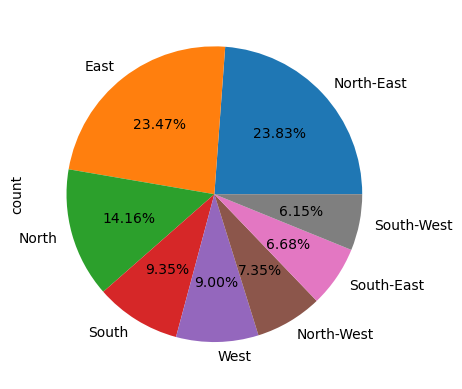

In [48]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [49]:

df.drop(columns=['nearbyLocations' , 'facing'],inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\118510209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['nearbyLocations' , 'facing'],inplace=True)


In [50]:
df.drop(columns=['furnishDetails' , 'features' , 'rating'] , inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\4236474289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['furnishDetails' , 'features' , 'rating'] , inplace=True)


# Age Possession

In [51]:
import pandas as pd
import numpy as np
import re

REFERENCE_DATE = pd.Timestamp('2026-08-08')


def process_age_possession(x):

    if pd.isna(x):
        return pd.Series(['Unknown', pd.NaT, np.nan, np.nan])

    x = str(x).strip()

    # Undefined
    if x.lower() == 'undefined':
        return pd.Series(['Unknown', pd.NaT, np.nan, np.nan])

    # Under construction
    if x.lower() == 'under construction':
        return pd.Series(['Under Construction', pd.NaT, np.nan, np.nan])

    # 0 to 1 Year Old
    match = re.search(r'0\s*to\s*1\s*Year', x, re.I)

    if match:
        return pd.Series([
            '0-1 Years Old',
            pd.NaT,
            0.5,
            np.nan
        ])

    # 1 to 5 Year Old
    match = re.search(r'1\s*to\s*5\s*Year', x, re.I)

    if match:
        return pd.Series([
            '1-5 Years Old',
            pd.NaT,
            3,
            np.nan
        ])

    # 5 to 10 Year Old
    match = re.search(r'5\s*to\s*10\s*Year', x, re.I)

    if match:
        return pd.Series([
            '5-10 Years Old',
            pd.NaT,
            7.5,
            np.nan
        ])

    # 10+ Year Old
    match = re.search(r'10\+\s*Year', x, re.I)

    if match:
        return pd.Series([
            '10+ Years Old',
            pd.NaT,
            12,
            np.nan
        ])

    # Within 3 months
    if 'within 3 months' in x.lower():
        date = REFERENCE_DATE + pd.DateOffset(months=3)

        return pd.Series([
            'Upcoming',
            date,
            0,
            date.year
        ])

    # Within 6 months
    if 'within 6 months' in x.lower():
        date = REFERENCE_DATE + pd.DateOffset(months=6)

        return pd.Series([
            'Upcoming',
            date,
            0,
            date.year
        ])

    # By YYYY
    match = re.search(r'By\s*(\d{4})', x, re.I)

    if match:
        year = int(match.group(1))
        date = pd.Timestamp(year=year, month=12, day=31)

        if date <= REFERENCE_DATE:
            age = (REFERENCE_DATE - date).days / 365.25
            status = 'Ready / Possessed'
        else:
            age = 0
            status = 'Upcoming'

        return pd.Series([
            status,
            date,
            round(age, 2),
            year
        ])

    # Month YYYY
    match = re.search(
        r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s*(\d{4})',
        x,
        re.I
    )

    if match:
        month = match.group(1)
        year = int(match.group(2))

        date = pd.to_datetime(
            f'{month} {year}',
            format='%b %Y'
        )

        if date <= REFERENCE_DATE:
            age = (REFERENCE_DATE - date).days / 365.25
            status = 'Ready / Possessed'
        else:
            age = 0
            status = 'Upcoming'

        return pd.Series([
            status,
            date,
            round(age, 2),
            year
        ])

    return pd.Series([
        'Unknown',
        pd.NaT,
        np.nan,
        np.nan
    ])

In [52]:
df[
    ['possession_status',
     'possession_date',
     'property_age_years',
     'possession_year']
] = df['agePossession'].apply(process_age_possession)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\4204859354.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[
C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\4204859354.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[
C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\4204859354.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

In [53]:
df.drop(columns=[ 'possession_date',
     'property_age_years',
     'possession_year'] , inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3705651180.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=[ 'possession_date',


In [54]:

df[df['possession_status'] == 'Unknown']

,Unnamed: 0,property_name,property_type,sector,society,price,price_per_sq_fit,bedRoom,bathroom,balcony,...,area_type,area_sqm,build_up,area_unit,built_up_area,luxury_score,luxury_category,property_age,bhk,possession_status
1,1,2 BHK Flat in Sohna,flat,sector 49,hcbs sports ville,0.38,5067.0,2,2,2,...,Carpet area: 650 sq.ft. (60.39 sq.m.),69.68,750.028552,sq.m.,750.0,3.9,Basic,NaN,2,Unknown
34,34,4 BHK Flat in Sector 92 Gurgaon,flat,sector 92,sare petioles,1.30,6373.0,4,4,No,...,NaN,189.52,2039.974328,sq.m.,2040.0,0.0,Unfurnished,NaN,4,Unknown
40,40,3 BHK Flat in Sector 92 Gurgaon,flat,sector 92,sare green parc,0.75,4820.0,3,2,2,...,Carpet area: 1261 sq.ft. (117.15 sq.m.),144.56,1556.029384,sq.m.,1556.0,0.0,Unfurnished,NaN,3,Unknown
55,55,2 BHK Flat in Sector 69 Gurgaon,flat,sector 69,tulip violet,1.20,10909.0,2,3,No,...,NaN,102.19,1099.962941,sq.m.,1100.0,0.0,Unfurnished,NaN,2,Unknown
68,68,3 BHK Flat in Sector 79 Gurgaon,flat,sector 79,mapsko mount ville,1.65,9091.0,3,3,No,...,NaN,168.62,1815.008818,sq.m.,1815.0,3.9,Basic,NaN,3,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3887,3887,3 Bedroom House for sale in Devilal Colony,house,sector 9,NaN,0.50,6083.0,3,2,1,...,Carpet area: 750 sq.ft. (69.68 sq.m.),76.37,822.039043,sq.m.,822.0,3.9,Basic,NaN,3,Unknown
3903,3903,5 Bedroom House for sale in Sector 82A Gurgaon,house,sector 82a,vatika sovereign next,3.85,7500.0,5,6,3+,...,NaN,477.52,5139.977528,sq.m.,5140.0,3.9,Basic,NaN,5,Unknown
3907,3907,2 BHK Flat in Sector 65 Gurgaon,flat,sector 65,m3m heights,2.15,15003.0,2,2,3+,...,NaN,133.13,1432.998007,sq.m.,1433.0,3.9,Basic,NaN,2,Unknown
3922,3922,2 BHK Flat in Sector 102 Gurgaon,flat,sector 102,shapoorji pallonji joyville gurugram,0.95,10383.0,2,2,2,...,Carpet area: 858 sq.ft. (79.71 sq.m.),85.01,915.039139,sq.m.,915.0,3.9,Basic,NaN,2,Unknown


In [55]:

def mode_based_imputation(row):
    if row['possession_status'] == 'Unknown':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['possession_status'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['possession_status']

In [56]:

df['possession_status'] = df.apply(mode_based_imputation,axis=1)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3496442642.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['possession_status'] = df.apply(mode_based_imputation,axis=1)


In [57]:
df['possession_status'].value_counts()

possession_status
1-5 Years Old         1649
0-1 Years Old          477
5-10 Years Old         417
Ready / Possessed      193
10+ Years Old          171
Unknown                116
Upcoming               109
Under Construction      83
Name: count, dtype: int64

In [58]:

def mode_based_imputation2(row):
    if row['possession_status'] == 'Unknown':
        mode_value = df[(df['sector'] == row['sector'])]['possession_status'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['possession_status']

In [59]:
df['possession_status'] = df.apply(mode_based_imputation2,axis=1)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3269477371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['possession_status'] = df.apply(mode_based_imputation2,axis=1)


In [60]:
df['possession_status'].value_counts()

possession_status
1-5 Years Old         1673
0-1 Years Old          478
5-10 Years Old         426
Ready / Possessed      194
10+ Years Old          187
Upcoming               109
Under Construction      83
Unknown                 65
Name: count, dtype: int64

In [61]:

def mode_based_imputation3(row):
    if row['possession_status'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['possession_status'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['possession_status']

In [62]:

df['possession_status'] = df.apply(mode_based_imputation3,axis=1)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3049312351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['possession_status'] = df.apply(mode_based_imputation3,axis=1)


In [63]:

df['possession_status'].value_counts()

possession_status
1-5 Years Old         1673
0-1 Years Old          478
5-10 Years Old         426
Ready / Possessed      194
10+ Years Old          187
Upcoming               109
Under Construction      83
Unknown                 65
Name: count, dtype: int64

In [64]:
df.isnull().sum()

Unnamed: 0              0
property_name           0
property_type           0
sector                  0
society               171
price                   0
price_per_sq_fit        0
bedRoom                 0
bathroom                0
balcony                 0
additionalRoom          0
address                 8
floorNum                0
agePossession           1
description             0
area_type            1943
area_sqm               27
build_up               27
area_unit              19
built_up_area           0
luxury_score            0
luxury_category         0
property_age         1056
bhk                     0
possession_status       0
dtype: int64

# society

In [65]:
df['society_from_name'] = (
    df['property_name']
    .astype(str)
    .str.extract(r'\bin\s+(.+)$', expand=False)
    .str.strip()
)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\3403337616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['society_from_name'] = (


In [66]:
print(
    df[['property_name', 'society_from_name']]
    .head(20)
    .to_string(index=False)
)

                                property_name  society_from_name
                          2 BHK Flat in Sohna              Sohna
                          2 BHK Flat in Sohna              Sohna
              2 BHK Flat in Sector 92 Gurgaon  Sector 92 Gurgaon
              2 BHK Flat in Sector 89 Gurgaon  Sector 89 Gurgaon
                3 BHK Flat in Sector-33 Sohna    Sector-33 Sohna
              4 BHK Flat in Sector 60 Gurgaon  Sector 60 Gurgaon
              3 BHK Flat in Sector 95 Gurgaon  Sector 95 Gurgaon
4 Bedroom House for sale in Sector 82 Gurgaon  Sector 82 Gurgaon
              2 BHK Flat in Sector 76 Gurgaon  Sector 76 Gurgaon
             3 BHK Flat in Sector 37D Gurgaon Sector 37D Gurgaon
              1 BHK Flat in Sector 95 Gurgaon  Sector 95 Gurgaon
             3 BHK Flat in Sector 102 Gurgaon Sector 102 Gurgaon
              3 BHK Flat in Sector 49 Gurgaon  Sector 49 Gurgaon
             3 BHK Flat in Sector 104 Gurgaon Sector 104 Gurgaon
              2 BHK Flat 

In [67]:
df['society'] = df['society'].fillna(df['society_from_name'])

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2351553803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['society'] = df['society'].fillna(df['society_from_name'])


In [68]:
df.isnull().sum()

Unnamed: 0              0
property_name           0
property_type           0
sector                  0
society                 0
price                   0
price_per_sq_fit        0
bedRoom                 0
bathroom                0
balcony                 0
additionalRoom          0
address                 8
floorNum                0
agePossession           1
description             0
area_type            1943
area_sqm               27
build_up               27
area_unit              19
built_up_area           0
luxury_score            0
luxury_category         0
property_age         1056
bhk                     0
possession_status       0
society_from_name       0
dtype: int64

In [69]:
df.drop(columns=['property_age'  , 'society_from_name' , 'description'] , inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\585800365.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['property_age'  , 'society_from_name' , 'description'] , inplace=True)


In [70]:
df['agePossession'] = df['possession_status']

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2932985204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['agePossession'] = df['possession_status']


In [71]:
df

,Unnamed: 0,property_name,property_type,sector,society,price,price_per_sq_fit,bedRoom,bathroom,balcony,...,agePossession,area_type,area_sqm,build_up,area_unit,built_up_area,luxury_score,luxury_category,bhk,possession_status
0,0,2 BHK Flat in Sohna,flat,sector 49,breez global hill view,0.35,6315.0,2,2,2,...,0-1 Years Old,NaN,51.48,554.125572,sq.m.,616.0,0.0,Unfurnished,2,0-1 Years Old
1,1,2 BHK Flat in Sohna,flat,sector 49,hcbs sports ville,0.38,5067.0,2,2,2,...,1-5 Years Old,Carpet area: 650 sq.ft. (60.39 sq.m.),69.68,750.028552,sq.m.,750.0,3.9,Basic,2,1-5 Years Old
2,2,2 BHK Flat in Sector 92 Gurgaon,flat,sector 92,sare crescent parc,0.49,4909.0,2,2,2,...,1-5 Years Old,NaN,92.72,998.028808,sq.m.,1109.0,0.0,Unfurnished,2,1-5 Years Old
3,3,2 BHK Flat in Sector 89 Gurgaon,flat,sector 89,greenopolis,0.80,4820.0,2,3,3,...,Under Construction,NaN,154.22,1660.008658,sq.m.,1660.0,0.0,Unfurnished,2,Under Construction
4,4,3 BHK Flat in Sector-33 Sohna,flat,sector-33 sector 49,godrej nature plus,1.55,9955.0,3,2,3+,...,Upcoming,NaN,144.65,1556.998135,sq.m.,1730.0,0.0,Unfurnished,3,Upcoming
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3935,3935,3 BHK Flat in Sector 109 Gurgaon,flat,sector 109,ats kocoon,2.20,10023.0,3,4,3,...,1-5 Years Old,Built Up area: 1860 sq.ft. (172.8 sq.m.),194.63,2094.977857,sq.m.,1860.0,69.3,Premium,3,1-5 Years Old
3936,3936,4 BHK Flat in Sector 62 Gurgaon,flat,sector 62,pioneer araya,7.56,18000.0,4,4,3+,...,1-5 Years Old,NaN,390.19,4199.966141,sq.m.,4200.0,212.1,Premium,4,1-5 Years Old
3937,3937,3 BHK Flat in Sector 36 Sohna,flat,sector 36 sector 49,signature global park 4,0.72,6660.0,3,2,3,...,Under Construction,NaN,100.43,1081.018477,sq.m.,1081.0,0.0,Unfurnished,3,Under Construction
3938,3938,2 BHK Flat in Sector 79 Gurgaon,flat,sector 79,m3m golfestate,1.40,10000.0,2,2,2,...,1-5 Years Old,NaN,130.06,1399.952834,sq.m.,1556.0,54.0,Premium,2,1-5 Years Old


# Sector

In [72]:
df[df['sector'].str.len() > 14]['sector'].unique()

array(['sector-33 sector 49', 'sector 3 phase 3 extension',
       'dwarka expressway', 'sector 36 sector 49', 'sector 3 phase 2'],
      dtype=object)

In [73]:
df['sector'] = df['sector'].str.replace(
    'sector-33 sector 49', 'sector 49', regex=False
)
df['sector'] = df['sector'].str.replace(
    'sector 3 phase 3 extension', 'sector 3', regex=False
)
df['sector'] = df['sector'].str.replace(
    'sector 36 sector 49', 'sector 33', regex=False
)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2046278407.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector'] = df['sector'].str.replace(
C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2046278407.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector'] = df['sector'].str.replace(
C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2046278407.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [74]:
df['sector'] = df['sector'].str.replace(
    'sector 3 phase 2', 'sector 3', regex=False
)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2527009452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector'] = df['sector'].str.replace(


In [75]:
df.drop(columns=['possession_status' , 'luxury_score'  , 'address' , 'price_per_sq_fit'  ] , inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\704237945.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['possession_status' , 'luxury_score'  , 'address' , 'price_per_sq_fit'  ] , inplace=True)


# Floor to categorical

In [76]:
def floor_cat(x):
    if(x <= 4):
        return "lower"
    elif(x < 9):
        return "middle"
    else:
        return "higher"
        

In [77]:
df['floor_cat'] = df['floorNum'].apply(floor_cat)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2442540960.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['floor_cat'] = df['floorNum'].apply(floor_cat)


In [78]:
df.isnull().sum()

Unnamed: 0            0
property_name         0
property_type         0
sector                0
society               0
price                 0
bedRoom               0
bathroom              0
balcony               0
additionalRoom        0
floorNum              0
agePossession         0
area_type          1943
area_sqm             27
build_up             27
area_unit            19
built_up_area         0
luxury_category       0
bhk                   0
floor_cat             0
dtype: int64

In [79]:
df.drop(columns=['property_name' , 'floorNum'] , inplace=True)

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\2343793502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['property_name' , 'floorNum'] , inplace=True)


In [81]:
df['diff'] = abs(df['built_up_area'] - df['build_up'])

C:\Users\aadarsh kumar verma\AppData\Local\Temp\ipykernel_24452\536177318.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['diff'] = abs(df['built_up_area'] - df['build_up'])


In [80]:
df.to_csv('../data/processed/gurgaon_property_cleaned.csv')